# 50 Hz downsampling check (valence respiration)

Load all valence respiration recordings, compute session-average breathing rate per file,
pick the fastest session, find a **local** window with resp rate above the session average,
then compare 400 Hz vs 100 Hz vs 50 Hz waveforms (1.5 s) with labeled samples at each rate.

In [22]:
import os
import sys
from pathlib import Path

_NB_DIR = Path.cwd()
if not (_NB_DIR / "resp_helper_functions.py").exists():
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
sys.path.insert(0, str(_NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from resp_helper_functions import load_clean_resp_signal, get_sniff_respiratory_rate

In [23]:
# ======================================================
# Respiration paths (VALENCE SETS ONLY) — same as feature_extraction-interactions-valence
# ======================================================

valence_h5_base = r"C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla-Coreano Lab\2025\ECG_cohort1\Aim1\AIM1\Day1_new\Resp_h5"

resp_paths_valence = {
    "RI1_3_6": os.path.join(valence_h5_base, "RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"),
    "RI2_3_6": os.path.join(valence_h5_base, "RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"),
    "RI1_4_7": os.path.join(valence_h5_base, "RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"),
    "RI2_4_7": os.path.join(valence_h5_base, "RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"),
    "RI1_2_3": os.path.join(valence_h5_base, "RI1_s2_3_p5_3_nRB3_20250622_104059_merged.h5"),
    "RI2_2_3": os.path.join(valence_h5_base, "RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"),
    "RI1_4_8": os.path.join(valence_h5_base, "RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"),
    "RI2_4_8": os.path.join(valence_h5_base, "RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"),
    "RI1_1_1": os.path.join(valence_h5_base, "RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5"),
    "RI2_1_1": os.path.join(valence_h5_base, "RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5"),
    "RI1_1_2": os.path.join(valence_h5_base, "RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5"),
    "RI2_1_2": os.path.join(valence_h5_base, "RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5"),
    "RI1_2_4": os.path.join(valence_h5_base, "RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5"),
    "RI2_2_4": os.path.join(valence_h5_base, "RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5"),
    "RI1_3_5": os.path.join(valence_h5_base, "RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5"),
    "RI2_3_5": os.path.join(valence_h5_base, "RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5"),
    "BLRI_1_1": os.path.join(valence_h5_base, "BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5"),
    "BLRI_1_2": os.path.join(valence_h5_base, "BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5"),
    "BLRI_2_3": os.path.join(valence_h5_base, "BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5"),
    "BLRI_2_4": os.path.join(valence_h5_base, "BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5"),
    "BLRI_3_6": os.path.join(valence_h5_base, "BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"),
    "BLRI_4_7": os.path.join(valence_h5_base, "BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"),
    "BLRI_4_8": os.path.join(valence_h5_base, "BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5"),
}

SESSION_RATE_FS = 100   # Hz — used for per-recording rate table + window search
COMPARE_RATES = [400, 100, 50]  # Hz — sampling rates to compare visually
TARGET_RATE = 50        # Hz — candidate RNN input rate
WINDOW_SEC = 1.5        # seconds shown in comparison plots
WINDOW_STRIDE_SEC = 0.1 # slide step when searching for a high-rate window

## 1. Session-average respiration rate per recording

Uses `load_clean_resp_signal` (raw `resp` → lowpass → downsample → bandpass, same as the valence notebooks)
and `get_sniff_respiratory_rate` (peak-based mean instantaneous 1/IBI).

In [24]:
rows = []
for trial, h5_path in resp_paths_valence.items():
    if not os.path.exists(h5_path):
        print(f"⚠️  missing: {trial}")
        continue

    signal, time, fs, meta = load_clean_resp_signal(
        h5_path, target_rate=SESSION_RATE_FS, verbose=False
    )
    if signal is None:
        print(f"❌ load failed: {trial}")
        continue

    avg_rate_hz = get_sniff_respiratory_rate(
        signal, time, time[0], time[-1], sampling_rate=fs
    )
    rows.append({
        "trial": trial,
        "avg_resp_rate_hz": avg_rate_hz,
        "avg_bpm": avg_rate_hz * 60 if np.isfinite(avg_rate_hz) else np.nan,
        "duration_sec": time[-1] - time[0],
        "n_samples": len(signal),
        "fs": fs,
        "h5_path": h5_path,
    })

rate_df = pd.DataFrame(rows).sort_values("avg_resp_rate_hz", ascending=False).reset_index(drop=True)
rate_df

,trial,avg_resp_rate_hz,avg_bpm,duration_sec,n_samples,fs,h5_path
0,RI1_2_4,8.808564,528.513840,609.09,60910,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
1,BLRI_1_2,8.614298,516.857894,610.97,61098,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
2,BLRI_2_4,8.588581,515.314876,603.95,60396,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
3,BLRI_4_8,8.390373,503.422396,605.01,60502,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
4,RI1_4_7,8.338957,500.337437,629.15,62916,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
5,RI1_1_2,8.294828,497.689688,604.47,60448,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
6,RI1_4_8,8.211164,492.669854,604.83,60484,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
7,RI1_2_3,8.207064,492.423862,602.94,60295,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
8,RI1_1_1,8.203861,492.231638,621.26,62127,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...
9,BLRI_3_6,8.182841,490.970442,606.28,60629,100,C:\Users\thoma\UF Dropbox\Thomas Heeps\Padilla...


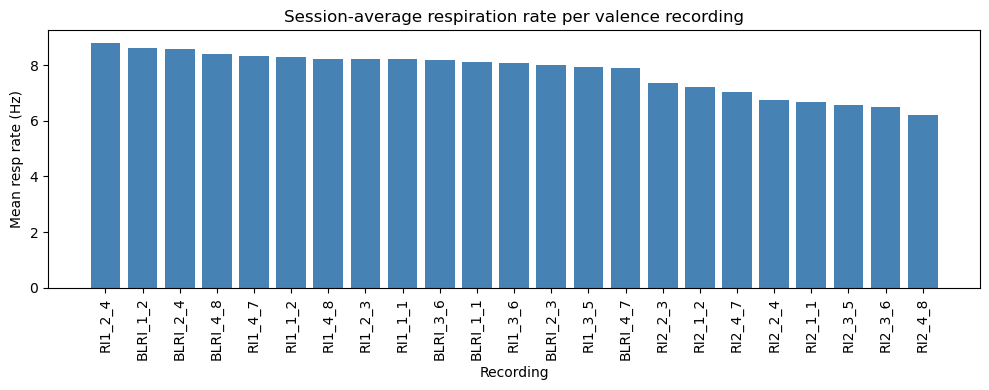

Fastest recording: RI1_2_4 @ 8.81 Hz (528.5 bpm)


In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(rate_df["trial"], rate_df["avg_resp_rate_hz"], color="steelblue")
ax.set_ylabel("Mean resp rate (Hz)")
ax.set_xlabel("Recording")
ax.set_title("Session-average respiration rate per valence recording")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

fastest = rate_df.iloc[0]
print(f"Fastest recording: {fastest['trial']} @ {fastest['avg_resp_rate_hz']:.2f} Hz ({fastest['avg_bpm']:.1f} bpm)")

## 2. Load fastest session at 400 / 100 / 50 Hz

Each trace uses the same `load_clean_resp_signal` pipeline; only the target sampling rate differs.

In [26]:
h5_fast = fastest["h5_path"]
trial_fast = fastest["trial"]
session_avg_hz = fastest["avg_resp_rate_hz"]

traces = {}
for rate in COMPARE_RATES:
    sig, time, fs, _ = load_clean_resp_signal(h5_fast, target_rate=rate, verbose=False)
    traces[rate] = {"sig": sig, "time": time, "fs": fs}
    print(f"  {rate} Hz: {len(sig)} samples, fs={fs}")

print(f"\n{trial_fast}: session avg = {session_avg_hz:.2f} Hz ({session_avg_hz * 60:.1f} bpm)")
print(f"Nyquist @ 50 Hz = {TARGET_RATE / 2} Hz (rodent breathing typically < 12 Hz)")

  400 Hz: 243639 samples, fs=400
  100 Hz: 60910 samples, fs=100
  50 Hz: 30455 samples, fs=50

RI1_2_4: session avg = 8.81 Hz (528.5 bpm)
Nyquist @ 50 Hz = 25.0 Hz (rodent breathing typically < 12 Hz)


## 3. Find a 1.5 s window with **above-average** local resp rate

Slide a fixed window across the session (on the 100 Hz trace) and pick the segment whose
peak-based breathing rate exceeds the session average — a stress test for fast breathing dynamics.

In [27]:
def find_high_rate_window(signal, time, fs, window_sec, session_avg_hz, stride_sec=0.1):
    """Return (t0, t1, local_rate_hz) for the fastest window above session average."""
    t_lo = time[0]
    t_hi = time[-1] - window_sec
    if t_hi <= t_lo:
        raise ValueError("Recording shorter than window length")

    best_above = None
    best_any = None

    t = t_lo
    while t <= t_hi + 1e-9:
        w0, w1 = t, t + window_sec
        local_hz = get_sniff_respiratory_rate(signal, time, w0, w1, sampling_rate=fs)
        if np.isfinite(local_hz):
            if best_any is None or local_hz > best_any[2]:
                best_any = (w0, w1, local_hz)
            if local_hz > session_avg_hz and (best_above is None or local_hz > best_above[2]):
                best_above = (w0, w1, local_hz)
        t += stride_sec

    if best_above is not None:
        return best_above
    print(f"Warning: no window above session avg ({session_avg_hz:.2f} Hz); using global max.")
    return best_any


sig_search = traces[SESSION_RATE_FS]["sig"]
time_search = traces[SESSION_RATE_FS]["time"]
fs_search = traces[SESSION_RATE_FS]["fs"]

t0, t1, local_rate_hz = find_high_rate_window(
    sig_search, time_search, fs_search,
    window_sec=WINDOW_SEC,
    session_avg_hz=session_avg_hz,
    stride_sec=WINDOW_STRIDE_SEC,
)

print(f"Session average:     {session_avg_hz:.2f} Hz")
print(f"Selected window:     [{t0:.3f}, {t1:.3f}] s  ({t1 - t0:.3f} s)")
print(f"Local window rate:   {local_rate_hz:.2f} Hz  ({local_rate_hz * 60:.1f} bpm)")
print(f"Above session avg:   {local_rate_hz > session_avg_hz}")

windows = {}
for rate in COMPARE_RATES:
    tr = traces[rate]
    m = (tr["time"] >= t0) & (tr["time"] <= t1)
    windows[rate] = {"w": tr["sig"][m], "tw": tr["time"][m], "fs": tr["fs"]}
    print(f"  {int(rate)} Hz -> {len(windows[rate]['w'])} samples in window")

Session average:     8.81 Hz
Selected window:     [424.000, 425.500] s  (1.500 s)
Local window rate:   10.78 Hz  (647.1 bpm)
Above session avg:   True
  400 Hz -> 600 samples in window
  100 Hz -> 150 samples in window
  50 Hz -> 75 samples in window


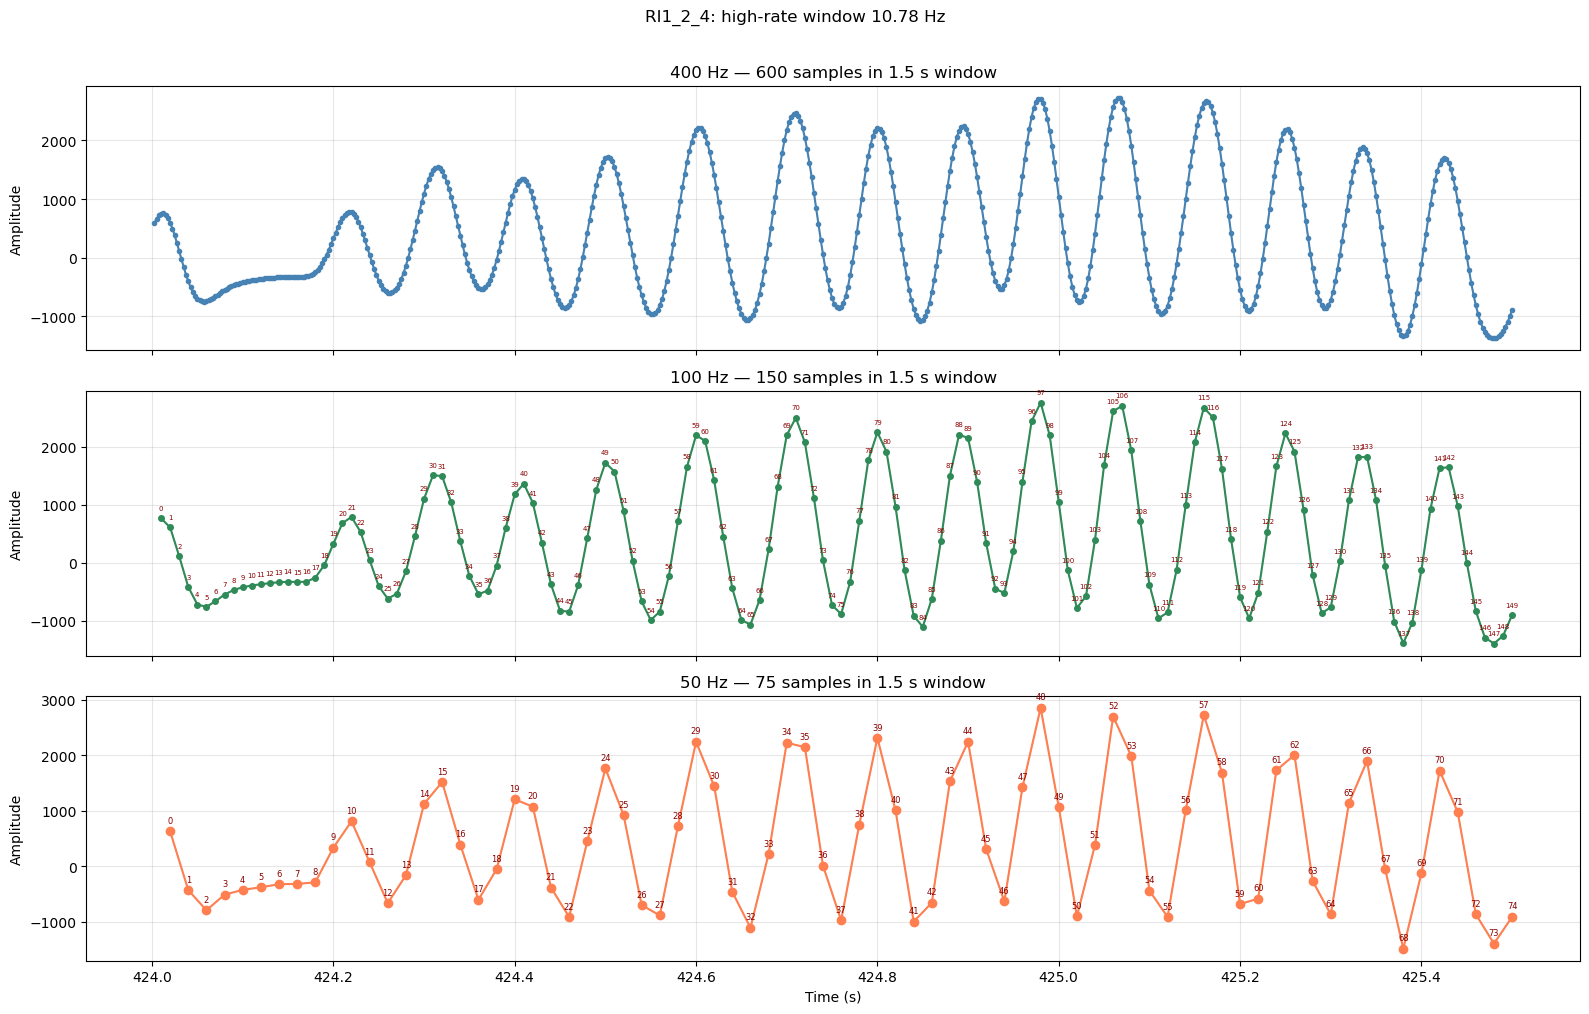

In [31]:
RATE_COLORS = {400: "steelblue", 100: "seagreen", 50: "coral"}

def plot_rate_panel(ax, rate, label_samples=True, ms=5, label_fs=6):
    w, tw = windows[rate]["w"], windows[rate]["tw"]
    ax.plot(tw, w, color="0.85", lw=1, zorder=1)
    ax.plot(tw, w, "-o", color=RATE_COLORS[rate], ms=ms, lw=1.5, zorder=2)
    if label_samples:
        for i, (ti, yi) in enumerate(zip(tw, w)):
            ax.annotate(
                str(i), (ti, yi), textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=label_fs, color="darkred",
            )
    ax.set_ylabel("Amplitude")
    ax.set_title(f"{int(rate)} Hz — {len(w)} samples in {WINDOW_SEC} s window")
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
plot_rate_panel(axes[0], 400, label_samples=False, ms=3)
plot_rate_panel(axes[1], 100, label_samples=True, ms=4, label_fs=5)
plot_rate_panel(axes[2], 50, label_samples=True, ms=6, label_fs=6)
axes[2].set_xlabel("Time (s)")

plt.suptitle(
    f"{trial_fast}: high-rate window {local_rate_hz:.2f} Hz",
    y=1.01, fontsize=12,
)
plt.tight_layout()
plt.show()

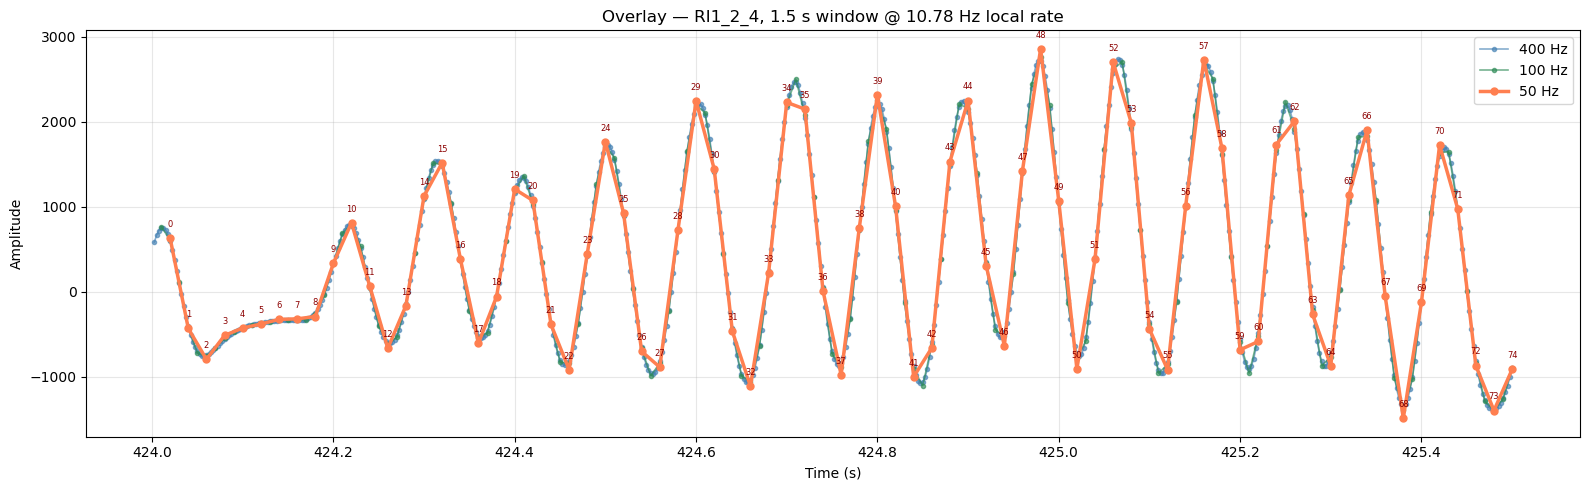

In [29]:
fig, ax = plt.subplots(figsize=(16, 5))
for rate in COMPARE_RATES:
    w, tw = windows[rate]["w"], windows[rate]["tw"]
    lw = 2.5 if rate == TARGET_RATE else 1.2
    alpha = 1.0 if rate == TARGET_RATE else 0.65
    ax.plot(tw, w, "-o", color=RATE_COLORS[rate], ms=5 if rate == TARGET_RATE else 3,
            lw=lw, alpha=alpha, label=f"{int(rate)} Hz")

w50, tw50 = windows[TARGET_RATE]["w"], windows[TARGET_RATE]["tw"]
for i, (ti, yi) in enumerate(zip(tw50, w50)):
    ax.annotate(str(i), (ti, yi), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=6, color="darkred")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(
    f"Overlay — {trial_fast}, {WINDOW_SEC} s window @ {local_rate_hz:.2f} Hz local rate"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Numeric summary (full session + high-rate window)

Compare 100 Hz and 50 Hz against 400 Hz (gold standard) over the full session and the selected high-rate window.

In [30]:
from scipy.interpolate import interp1d

GOLD_RATE = 400

def compare_to_gold(sig_gold, time_gold, sig_test, time_test):
    f = interp1d(time_test, sig_test, kind="linear", bounds_error=False, fill_value="extrapolate")
    on_gold = f(time_gold)
    residual = sig_gold - on_gold
    return {
        "rmse": float(np.sqrt(np.mean(residual ** 2))),
        "r": float(np.corrcoef(sig_gold, on_gold)[0, 1]),
    }

def slice_mask(time, t0, t1):
    return (time >= t0) & (time <= t1)

gold = traces[GOLD_RATE]
summary_rows = []
for rate in [100, 50]:
    test = traces[rate]
    for scope, mask_fn in [
        ("full_session", lambda t: np.ones(len(t), dtype=bool)),
        ("high_rate_window", lambda t: slice_mask(t, t0, t1)),
    ]:
        mg = mask_fn(gold["time"])
        mt = mask_fn(test["time"])
        stats = compare_to_gold(gold["sig"][mg], gold["time"][mg], test["sig"][mt], test["time"][mt])
        summary_rows.append({"rate_hz": rate, "scope": scope, **stats})

summary_df = pd.DataFrame(summary_rows)
summary_df

print(f"RNN window sizing ({trial_fast}):")
for rate in COMPARE_RATES:
    print(f"  {WINDOW_SEC} s @ {int(rate)} Hz -> {int(rate * WINDOW_SEC)} samples")
print(f"  5 s @ {TARGET_RATE} Hz -> {int(TARGET_RATE * 5)} samples")
print(f"  5 s @ 100 Hz -> {int(100 * 5)} samples")
print(f"  5 s @ 400 Hz -> {int(400 * 5)} samples")

RNN window sizing (RI1_2_4):
  1.5 s @ 400 Hz -> 600 samples
  1.5 s @ 100 Hz -> 150 samples
  1.5 s @ 50 Hz -> 75 samples
  5 s @ 50 Hz -> 250 samples
  5 s @ 100 Hz -> 500 samples
  5 s @ 400 Hz -> 2000 samples
